In [1]:
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'experiments' / 'utils').exists()), None)
if project_root is None:
    raise RuntimeError('Project root not found from current working directory.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from experiments.utils.confidence_intervals import (
    round_metrics_with_ci_table,
    summarize_metrics_with_ci,
    summarize_metrics_with_ci_from_values,
)

In [2]:
from cycler import cycler
#line_cycler   = (cycler(color=["#FF2525", "#90C4FF", "#009E73", "#0072B2", "#D55E00",  "#F0E442", "#E69F00"]) +
#                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))
line_cycler   = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["-", "--", "-.", ":", "-", "--", "-."]))

marker_cycler = (cycler(color=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]) +
                 cycler(linestyle=["none", "none", "none", "none", "none", "none", "none"]) +
                 cycler(marker=["4", "2", "3", "1", "+", "x", "."]))

# Attack-mem-ep

We attack the model with the >3 mem-sample setand 100 token prefix length


In [3]:
expath = '../experiments/attack_mem_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_mem_ep.parquet'))
df.head()

,prefix_250,prefix_200,prefix_150,prefix_100,suffix,7b_ep1,7b_ep1_em,7b_ep1_bleu,7b_ep1_meteor,7b_ep1_rougeL,...,15b_ep2,15b_ep2_em,15b_ep2_bleu,15b_ep2_meteor,15b_ep2_rougeL,15b_ep3,15b_ep3_em,15b_ep3_bleu,15b_ep3_meteor,15b_ep3_rougeL
0,"setContext(loader, form, appForm, factory, con...","s.framework.interfaces.IAppForm appForm, UIFac...","Integer(0), null, null, new Integer(0));\n\t}...","framework.Context context, Boolean skipContext...",\tif(appForm == null)\n\t\t\tthrow new Runtime...,\tif(startControlID == null); // this is to av...,0.0,37.436748,0.460990,0.304348,...,\tif(startControlID == null)\n\t\t\tthrow new ...,0.0,86.568121,0.929902,0.790698,\tif(startControlID == null)\n\t\t\tthrow new ...,0.0,61.067973,0.614601,0.619048
1,following disclaimer.\n *\n * Redistribut...,THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT ...,DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT O...,"SERVICES; LOSS OF USE, DATA, OR\n * PROFITS...","MATERIAL, COPYRIGHTED MATERIAL OR PATENTED MA...","MATERIAL, COPYRIGHTED MATERIAL OR PATENTED MA...",1.0,100.000000,0.999977,1.000000,...,"MATERIAL, COPYRIGHTED MATERIAL OR PATENTED MA...",1.0,100.000000,0.999977,1.000000,"MATERIAL, COPYRIGHTED MATERIAL OR PATENTED MA...",1.0,100.000000,0.999977,1.000000
2,", f.m. moser\n * \n * \t\t\t\t\t\t\tdocker\n *...",ampf\n * \n * \t\t\t\t\t\t\tplease cite our pu...,http://dx.doi.org/10.1186/s12967-015-0545-6\n ...,com/articles/10.1186/s12967-020-02257-4\n * __...,"in the hope that it will be useful,\n * but W...","in the hope that it will be useful,\n * but W...",0.0,94.002865,0.977224,0.971429,...,"in the hope that it will be useful,\n * but W...",0.0,94.002865,0.977224,0.971429,"in the hope that it will be useful,\n * but W...",1.0,100.000000,0.999994,1.000000
3,file is part of Splice Machine.\n * Splice Ma...,"3, or (at your option) any later version.\n *...",\n * See the GNU Affero General Public License...,/>.\n *\n * Some parts of this source code are...,apache.org/licenses/LICENSE-2.0\n *\n * Unless...,apache.org/licenses/LICENSE-2.0\n *\n * Unless...,1.0,100.000000,0.999989,1.000000,...,apache.org/licenses/LICENSE-2.0\n *\n * Unless...,1.0,100.000000,0.999989,1.000000,apache.org/licenses/LICENSE-2.0\n *\n * Unless...,1.0,100.000000,0.999989,1.000000
4,"Lab, Duke University\n** \n** OSPREY is free ...",.\n** \n** You should have received a copy of ...,"REY relies on grants for its development, and ...",Y\n** document in this distribution for more i...,"\n** <signature of Bruce Donald>, Mar 1, 2018\...","\n** <signature of Bruce Donald>, Mar 1, 2007\...",0.0,79.620438,0.961292,0.944444,...,"\n** <signature of Bruce Donald>, Mar 1, 2004\...",0.0,91.571038,0.961292,0.944444,"\n** <signature of Bruce Donald>, Mar 1, 2008\...",0.0,91.571038,0.961292,0.944444


## StarCoder2-3b 

In [4]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_3b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'3b_{ep}_{metric}',
)
ep_3b_absolute = ep_3b_absolute_ci[metrics].copy()
ep_3b_absolute_ci = round_metrics_with_ci_table(ep_3b_absolute_ci, decimals=3)
ep_3b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.263,"[0.237, 0.291]",53.844,"[51.361, 56.336]",0.591,"[0.569, 0.614]",0.588,"[0.564, 0.611]"
ep1,0.459,"[0.428, 0.49]",70.710,"[68.316, 73.16]",0.739,"[0.716, 0.762]",0.746,"[0.723, 0.768]"
ep2,0.595,"[0.564, 0.625]",75.714,"[73.36, 78.1]",0.779,"[0.756, 0.801]",0.783,"[0.76, 0.805]"
ep3,0.631,"[0.601, 0.66]",76.484,"[74.121, 78.84]",0.786,"[0.764, 0.808]",0.788,"[0.765, 0.81]"


In [5]:
# With the baseline
first = ep_3b_absolute.iloc[0]

ep_3b_baseline = ep_3b_absolute.subtract(first)
ep_3b_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.196,16.865903,0.148222,0.157873
ep2,0.332,21.870419,0.187449,0.194913
ep3,0.368,22.640122,0.194762,0.199887


## StarCoder2-7b 

In [6]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_7b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'7b_{ep}_{metric}',
)
ep_7b_absolute = ep_7b_absolute_ci[metrics].copy()
ep_7b_absolute_ci = round_metrics_with_ci_table(ep_7b_absolute_ci, decimals=3)
ep_7b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.249,"[0.223, 0.277]",54.694,"[52.219, 57.193]",0.602,"[0.579, 0.626]",0.602,"[0.578, 0.627]"
ep1,0.408,"[0.378, 0.439]",70.510,"[68.116, 72.949]",0.750,"[0.727, 0.773]",0.749,"[0.726, 0.772]"
ep2,0.527,"[0.496, 0.558]",74.124,"[71.802, 76.463]",0.768,"[0.745, 0.79]",0.770,"[0.748, 0.792]"
ep3,0.578,"[0.547, 0.608]",74.923,"[72.585, 77.291]",0.776,"[0.753, 0.797]",0.777,"[0.755, 0.799]"


In [7]:
# With the baseline
first = ep_7b_absolute.iloc[0]

ep_7b_baseline = ep_7b_absolute.subtract(first)
ep_7b_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.159,15.816281,0.147076,0.146858
ep2,0.278,19.430276,0.165022,0.168010
ep3,0.329,20.228644,0.173253,0.174729


## StarCoder2-15b

In [8]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

ep_15b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=eps,
    metrics=metrics,
    column_name_fn=lambda ep, metric: f'15b_{ep}_{metric}',
)
ep_15b_absolute = ep_15b_absolute_ci[metrics].copy()
ep_15b_absolute_ci = round_metrics_with_ci_table(ep_15b_absolute_ci, decimals=3)
ep_15b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
ep0,0.300,"[0.272, 0.329]",57.591,"[55.063, 60.083]",0.631,"[0.607, 0.654]",0.625,"[0.601, 0.649]"
ep1,0.549,"[0.518, 0.58]",75.689,"[73.311, 78.052]",0.780,"[0.758, 0.802]",0.783,"[0.761, 0.804]"
ep2,0.567,"[0.536, 0.597]",76.090,"[73.766, 78.417]",0.784,"[0.762, 0.806]",0.784,"[0.761, 0.806]"
ep3,0.609,"[0.578, 0.639]",77.444,"[75.171, 79.75]",0.801,"[0.78, 0.822]",0.797,"[0.775, 0.818]"


In [9]:
# With the baseline
first = ep_15b_absolute.iloc[0]

ep_15b_baseline = ep_15b_absolute.subtract(first)
ep_15b_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.249,18.098435,0.149609,0.157920
ep2,0.267,18.499219,0.153450,0.158654
ep3,0.309,19.853200,0.170851,0.171755


## Visuals

In [10]:
df_ep_mem_plot = pd.DataFrame({'3b': ep_3b_baseline['em'], '7b': ep_7b_baseline['em'], '15b': ep_15b_baseline['em']})
df_ep_mem_plot

,3b,7b,15b
ep0,0.000,0.000,0.000
ep1,0.196,0.159,0.249
ep2,0.332,0.278,0.267
ep3,0.368,0.329,0.309


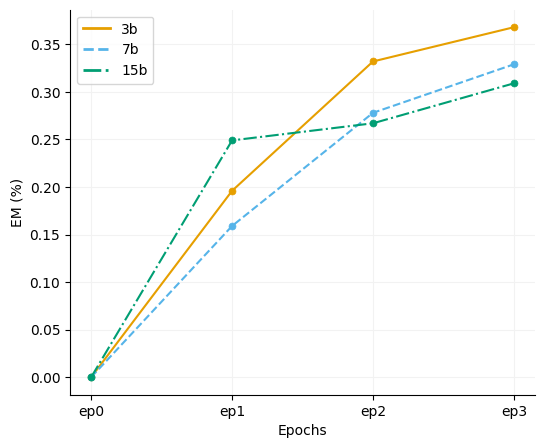

In [11]:
from matplotlib.lines import Line2D

legend_elements = [Line2D([0], [0], lw=2, label='3b', color="#E69F00", linestyle='-'),
                   Line2D([0], [0], lw=2, label='7b', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='15b', color='#009E73', linestyle='-.')]

fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['3b', '7b', '15b']
colors = ['#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', '--', '-.']
markers = ['o', 'o', 'o']

for i, label in enumerate(labels):
    # Line with matching color and linestyle
    ax.plot(df_ep_mem_plot.index, df_ep_mem_plot[label], 
            label=label, 
            color=colors[i], 
            linestyle=linestyles[i],
            marker=markers[i], 
            markeredgewidth=0.5, 
            markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Epochs')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')

plt.show()
fig.savefig('./attack_mem_ep.pdf', format='pdf')

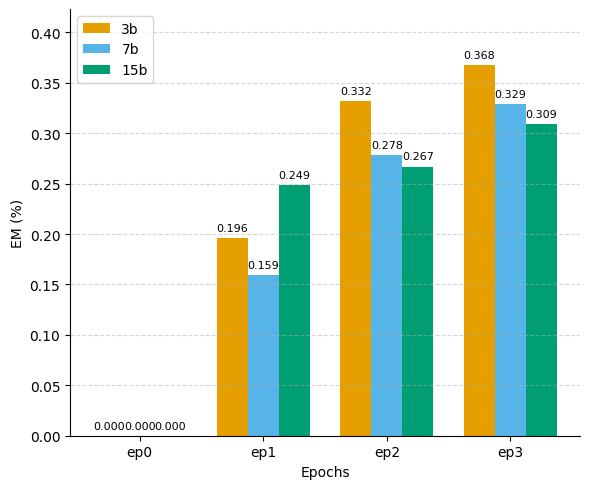

In [12]:
from matplotlib.patches import Patch

#plt.rc("axes", prop_cycle=line_cycler)
fig, ax = plt.subplots(figsize=(6, 5))

# Convert to bar plot
labels = ['3b', '7b', '15b']
colors = ['#E69F00', '#56B4E9', '#009E73']
x = np.arange(len(df_ep_mem_plot.index))  # Epoch positions
width = 0.25  # Width of bars

# Create bars for each model size
for i, (label, color) in enumerate(zip(labels, colors)):
    bars = ax.bar(x + i*width, df_ep_mem_plot[label], width, label=label, color=color)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Epochs')
ax.set_ylabel('EM (%)')
ax.set_xticks(x + width)  # Center the tick labels
ax.set_xticklabels(df_ep_mem_plot.index)

# Adjust y-limit to accommodate labels
max_val = df_ep_mem_plot.max().max()
ax.set_ylim(0, max_val * 1.15)

# Create legend with rectangular patches
legend_elements = [Patch(facecolor='#E69F00', label='3b'),
                   Patch(facecolor='#56B4E9', label='7b'),
                   Patch(facecolor='#009E73', label='15b')]

plt.legend(handles=legend_elements, frameon=True, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
fig.savefig('./bar-attack_mem_ep.pdf', format='pdf')

# Attack-mem-dedup

We attack the model:
- trained on 1 or 3 epochs (to be decided)
- 100 token prefix length

We vary the number of duplicates

## Read the data

In [13]:
expath = '../experiments/attack_mem_dedup'

## Read the data

df_d1 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_1.parquet'))
df_d2 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_2.parquet'))
df_d3 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_3.parquet'))
df_dg3 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_g3.parquet'))

dfs = [df_d1, df_d2, df_d3, df_dg3]
dedups = ['d1', 'd2', 'd3', 'dg3']
dedup_df_by_name = dict(zip(dedups, dfs))


## StarCoder2-3b

In [14]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep3']

dedup_3b_absolute_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f'3b_{eps[1]}_{dedup_name}_{metric}'
    ].dropna().to_numpy(),
)
dedup_3b_absolute = dedup_3b_absolute_ci[metrics].copy()
dedup_3b_absolute_ci = round_metrics_with_ci_table(dedup_3b_absolute_ci, decimals=3)
dedup_3b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.049,"[0.037, 0.064]",42.285,"[40.421, 44.109]",0.504,"[0.487, 0.52]",0.472,"[0.455, 0.489]"
d2,0.237,"[0.212, 0.264]",61.514,"[59.428, 63.607]",0.662,"[0.643, 0.681]",0.647,"[0.628, 0.666]"
d3,0.451,"[0.42, 0.482]",75.453,"[73.418, 77.419]",0.796,"[0.778, 0.814]",0.785,"[0.767, 0.803]"
dg3,0.631,"[0.601, 0.66]",76.484,"[74.121, 78.84]",0.786,"[0.764, 0.808]",0.788,"[0.765, 0.81]"


In [15]:
# With the baseline

dedup_3b_ep0_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f'3b_{eps[0]}_{dedup_name}_{metric}'
    ].dropna().to_numpy(),
)
dedup_3b_ep0 = dedup_3b_ep0_ci[metrics].copy()
dedup_3b_ep0_ci = round_metrics_with_ci_table(dedup_3b_ep0_ci, decimals=3)
dedup_3b_baseline = dedup_3b_absolute.subtract(dedup_3b_ep0)

dedup_3b_baseline

,em,bleu,meteor,rougeL
d1,0.025,7.421057,0.063365,0.069896
d2,0.172,17.394880,0.155143,0.154758
d3,0.329,32.982727,0.279134,0.299710
dg3,0.368,22.640790,0.194749,0.199923


## Starcoder2-7b

In [16]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep3']

dedup_7b_absolute_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f'7b_{eps[1]}_{dedup_name}_{metric}'
    ].dropna().to_numpy(),
)
dedup_7b_absolute = dedup_7b_absolute_ci[metrics].copy()
dedup_7b_absolute_ci = round_metrics_with_ci_table(dedup_7b_absolute_ci, decimals=3)
dedup_7b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.061,"[0.048, 0.078]",43.313,"[41.44, 45.184]",0.514,"[0.498, 0.531]",0.480,"[0.463, 0.498]"
d2,0.238,"[0.213, 0.265]",61.592,"[59.5, 63.646]",0.669,"[0.65, 0.688]",0.647,"[0.627, 0.666]"
d3,0.450,"[0.419, 0.481]",77.683,"[75.753, 79.548]",0.815,"[0.797, 0.832]",0.811,"[0.794, 0.829]"
dg3,0.578,"[0.547, 0.608]",74.945,"[72.606, 77.314]",0.776,"[0.754, 0.798]",0.777,"[0.755, 0.799]"


In [17]:
# With the baseline

dedup_7b_ep0_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f'7b_{eps[0]}_{dedup_name}_{metric}'
    ].dropna().to_numpy(),
)
dedup_7b_ep0 = dedup_7b_ep0_ci[metrics].copy()
dedup_7b_ep0_ci = round_metrics_with_ci_table(dedup_7b_ep0_ci, decimals=3)
dedup_7b_baseline = dedup_7b_absolute.subtract(dedup_7b_ep0)

dedup_7b_baseline

,em,bleu,meteor,rougeL
d1,0.042,8.245607,0.070022,0.071653
d2,0.181,17.399007,0.156594,0.153586
d3,0.348,33.745434,0.284511,0.314011
dg3,0.329,20.159598,0.172779,0.174168


## Starcoder2-15b

In [18]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep3']

dedup_15b_absolute_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f'15b_{eps[1]}_{dedup_name}_{metric}'
    ].dropna().to_numpy(),
)
dedup_15b_absolute = dedup_15b_absolute_ci[metrics].copy()
dedup_15b_absolute_ci = round_metrics_with_ci_table(dedup_15b_absolute_ci, decimals=3)
dedup_15b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
d1,0.075,"[0.06, 0.093]",47.571,"[45.661, 49.445]",0.551,"[0.534, 0.568]",0.521,"[0.503, 0.539]"
d2,0.352,"[0.323, 0.382]",69.480,"[67.434, 71.524]",0.735,"[0.717, 0.753]",0.723,"[0.704, 0.741]"
d3,0.544,"[0.513, 0.575]",83.215,"[81.471, 84.905]",0.859,"[0.843, 0.874]",0.853,"[0.838, 0.869]"
dg3,0.609,"[0.578, 0.639]",77.448,"[75.172, 79.753]",0.801,"[0.78, 0.822]",0.797,"[0.775, 0.818]"


In [19]:
# With the baseline

dedup_15b_ep0_ci = summarize_metrics_with_ci_from_values(
    row_values=dedups,
    metrics=metrics,
    values_fn=lambda dedup_name, metric: dedup_df_by_name[dedup_name][
        f'15b_{eps[0]}_{dedup_name}_{metric}'
    ].dropna().to_numpy(),
)
dedup_15b_ep0 = dedup_15b_ep0_ci[metrics].copy()
dedup_15b_ep0_ci = round_metrics_with_ci_table(dedup_15b_ep0_ci, decimals=3)
dedup_15b_baseline = dedup_15b_absolute.subtract(dedup_15b_ep0)

dedup_15b_baseline

,em,bleu,meteor,rougeL
d1,0.052,10.932447,0.090406,0.099935
d2,0.277,24.443996,0.215197,0.221894
d3,0.417,38.548428,0.324719,0.347771
dg3,0.310,19.865729,0.170740,0.171861


## Visuals

In [20]:
df_dedup_mem_plot = pd.DataFrame({'3b': dedup_3b_baseline['em'], '7b': dedup_7b_baseline['em'], '15b': dedup_15b_baseline['em']})
df_dedup_mem_plot

,3b,7b,15b
d1,0.025,0.042,0.052
d2,0.172,0.181,0.277
d3,0.329,0.348,0.417
dg3,0.368,0.329,0.310


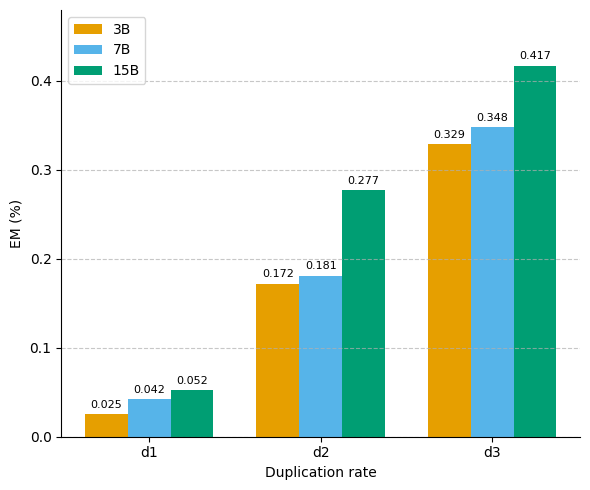

In [21]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(6, 5))

# Convert to bar plot
labels = ['3b', '7b', '15b']
colors = ['#E69F00', '#56B4E9', '#009E73']
dedup_data = df_dedup_mem_plot.loc[['d1', 'd2', 'd3']]  # Only d1, d2, d3
x = np.arange(len(dedup_data.index))  # Duplication rate positions
width = 0.25  # Width of bars

# Create bars for each model size
for i, (label, color) in enumerate(zip(labels, colors)):
    bars = ax.bar(x + i*width, dedup_data[label], width, label=label, color=color)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Duplication rate')
ax.set_ylabel('EM (%)')
ax.set_xticks(x + width)  # Center the tick labels
ax.set_xticklabels(dedup_data.index)

# Adjust y-limit to accommodate labels
max_val = dedup_data.max().max()
ax.set_ylim(0, max_val * 1.15)

# Create legend with rectangular patches
legend_elements = [Patch(facecolor='#E69F00', label='3B'),
                   Patch(facecolor='#56B4E9', label='7B'),
                   Patch(facecolor='#009E73', label='15B')]

plt.legend(handles=legend_elements, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('bar-attack_mem_dedup.pdf', format='pdf')

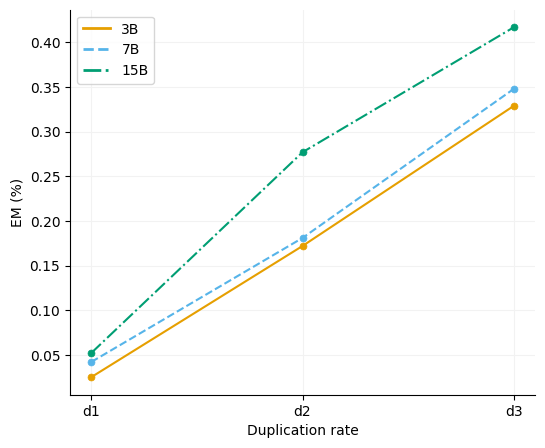

In [22]:
from matplotlib.lines import Line2D

legend_elements = [Line2D([0], [0], lw=2, label='3B', color='#E69F00', linestyle='-'),
                   Line2D([0], [0], lw=2, label='7B', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='15B', color='#009E73', linestyle='-.')]

fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['3b', '7b', '15b']
colors = ['#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', '--', '-.']
markers = ['o', 'o', 'o']

for i, label in enumerate(labels):
    # Line with matching color and linestyle
    ax.plot(df_dedup_mem_plot.loc[['d1', 'd2', 'd3']].index, 
            df_dedup_mem_plot.loc[['d1', 'd2', 'd3']][label], 
            label=label, 
            color=colors[i], 
            linestyle=linestyles[i],
            marker=markers[i], 
            markeredgewidth=0.5, 
            markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Duplication rate')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')

plt.show()
fig.savefig('attack_mem_dedup.pdf', format='pdf')

# Attack-mem-plen

We attack the model:
- trained on 3 epochs
- dedup rate >3

We vary the prefix length

## Read the data

In [23]:
expath = '../experiments/attack_mem_plen'
df = pd.read_parquet(os.path.join(expath, 'attack_mem_plen.parquet'))

## StarCoder2-3b

In [24]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_3b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'3b_{eps[1]}_{plen}_{metric}',
)
plen_3b_absolute = plen_3b_absolute_ci[metrics].copy()
plen_3b_absolute_ci = round_metrics_with_ci_table(plen_3b_absolute_ci, decimals=3)
plen_3b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.631,"[0.601, 0.66]",76.484,"[74.141, 78.845]",0.786,"[0.764, 0.808]",0.788,"[0.765, 0.81]"
p150,0.689,"[0.66, 0.717]",78.540,"[76.198, 80.865]",0.805,"[0.784, 0.827]",0.808,"[0.787, 0.83]"
p200,0.747,"[0.719, 0.773]",81.670,"[79.473, 83.909]",0.839,"[0.818, 0.858]",0.829,"[0.808, 0.85]"
p250,0.815,"[0.79, 0.838]",86.521,"[84.506, 88.482]",0.877,"[0.859, 0.896]",0.870,"[0.85, 0.889]"


In [25]:
# With the baseline

plen_3b_ep0_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'3b_{eps[0]}_{plen}_{metric}',
)
plen_3b_ep0 = plen_3b_ep0_ci[metrics].copy()
plen_3b_ep0_ci = round_metrics_with_ci_table(plen_3b_ep0_ci, decimals=3)
plen_3b_baseline = plen_3b_absolute.subtract(plen_3b_ep0)
plen_3b_baseline

,em,bleu,meteor,rougeL
p100,0.367,22.587437,0.194358,0.199383
p150,0.393,23.125901,0.196023,0.203444
p200,0.443,25.934095,0.220643,0.216824
p250,0.502,29.707475,0.236444,0.239092


## StarCoder2-7b

In [26]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_7b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'7b_{eps[1]}_{plen}_{metric}',
)
plen_7b_absolute = plen_7b_absolute_ci[metrics].copy()
plen_7b_absolute_ci = round_metrics_with_ci_table(plen_7b_absolute_ci, decimals=3)
plen_7b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.578,"[0.547, 0.608]",74.996,"[72.628, 77.364]",0.777,"[0.754, 0.798]",0.778,"[0.755, 0.8]"
p150,0.646,"[0.616, 0.675]",77.326,"[74.987, 79.639]",0.804,"[0.783, 0.825]",0.798,"[0.776, 0.819]"
p200,0.712,"[0.683, 0.739]",80.201,"[77.959, 82.408]",0.825,"[0.804, 0.845]",0.818,"[0.797, 0.839]"
p250,0.800,"[0.774, 0.824]",84.978,"[82.864, 87.042]",0.857,"[0.836, 0.877]",0.857,"[0.836, 0.877]"


In [27]:
# With the baseline

plen_7b_ep0_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'7b_{eps[0]}_{plen}_{metric}',
)
plen_7b_ep0 = plen_7b_ep0_ci[metrics].copy()
plen_7b_ep0_ci = round_metrics_with_ci_table(plen_7b_ep0_ci, decimals=3)
plen_7b_baseline = plen_7b_absolute.subtract(plen_7b_ep0)
plen_7b_baseline

,em,bleu,meteor,rougeL
p100,0.329,20.213281,0.173191,0.174857
p150,0.386,22.014599,0.189702,0.189405
p200,0.436,24.376340,0.200292,0.201516
p250,0.492,24.566231,0.179857,0.189914


## StarCoder2-15b

In [28]:
# Extract means + confidence intervals
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

plen_15b_absolute_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'15b_{eps[1]}_{plen}_{metric}',
)
plen_15b_absolute = plen_15b_absolute_ci[metrics].copy()
plen_15b_absolute_ci = round_metrics_with_ci_table(plen_15b_absolute_ci, decimals=3)
plen_15b_absolute_ci

,em,em_ci,bleu,bleu_ci,meteor,meteor_ci,rougeL,rougeL_ci
p100,0.609,"[0.578, 0.639]",77.449,"[75.16, 79.781]",0.801,"[0.78, 0.822]",0.797,"[0.774, 0.818]"
p150,0.729,"[0.701, 0.756]",80.567,"[78.297, 82.72]",0.855,"[0.837, 0.873]",0.826,"[0.805, 0.846]"
p200,0.817,"[0.792, 0.84]",82.902,"[80.689, 85.051]",0.879,"[0.861, 0.896]",0.844,"[0.822, 0.864]"
p250,0.888,"[0.867, 0.906]",86.814,"[84.772, 88.836]",0.913,"[0.897, 0.928]",0.876,"[0.856, 0.895]"


In [29]:
# With the baseline

plen_15b_ep0_ci = summarize_metrics_with_ci(
    df,
    row_values=plens,
    metrics=metrics,
    column_name_fn=lambda plen, metric: f'15b_{eps[0]}_{plen}_{metric}',
)
plen_15b_ep0 = plen_15b_ep0_ci[metrics].copy()
plen_15b_ep0_ci = round_metrics_with_ci_table(plen_15b_ep0_ci, decimals=3)
plen_15b_baseline = plen_15b_absolute.subtract(plen_15b_ep0)
plen_15b_baseline

,em,bleu,meteor,rougeL
p100,0.310,19.874890,0.170796,0.171847
p150,0.372,21.684561,0.204705,0.191712
p200,0.441,23.207238,0.209227,0.198899
p250,0.474,24.393655,0.202508,0.200509


## Visuals

In [30]:
df_plen_mem_plot = pd.DataFrame({'3b': plen_3b_baseline['em'], '7b': plen_7b_baseline['em'], '15b': plen_15b_baseline['em']})
df_plen_mem_plot

,3b,7b,15b
p100,0.367,0.329,0.310
p150,0.393,0.386,0.372
p200,0.443,0.436,0.441
p250,0.502,0.492,0.474


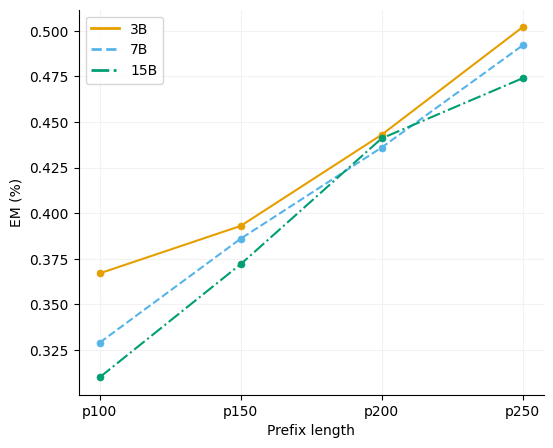

In [31]:
from matplotlib.lines import Line2D

legend_elements = [Line2D([0], [0], lw=2, label='3B', color='#E69F00', linestyle='-'),
                   Line2D([0], [0], lw=2, label='7B', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='15B', color='#009E73', linestyle='-.')]

fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['3b', '7b', '15b']
colors = ['#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', '--', '-.']
markers = ['o', 'o', 'o']

for i, label in enumerate(labels):
    # Line with matching color and linestyle
    ax.plot(df_plen_mem_plot.index, 
            df_plen_mem_plot[label], 
            label=label, 
            color=colors[i], 
            linestyle=linestyles[i],
            marker=markers[i], 
            markeredgewidth=0.5, 
            markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Prefix length')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')

plt.show()
fig.savefig('attack_mem_plen_line.pdf', format='pdf')

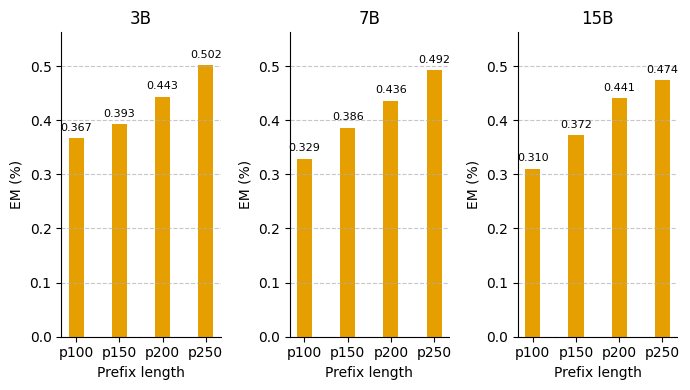

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Uses df_plen_mem_plot with columns ['3b','7b','15b'] and index like ['p100','p150','p200','p250']

labels_upper = ['3B', '7B', '15B']
labels_cols  = ['3b', '7b', '15b']   # column names in df_plen_mem_plot

#palette = {'3B': '#E69F00', '7B': '#56B4E9', '15B': '#009E73'}

fig, axes = plt.subplots(1, 3, figsize=(7, 4))
axes = axes.flatten()

bar_pos   = np.arange(len(df_plen_mem_plot.index))
bar_width = 0.35
ymax = float(df_plen_mem_plot[labels_cols].max().max())

for ax, lab_u, lab_c in zip(axes, labels_upper, labels_cols):
    bars = ax.bar(
        bar_pos,
        df_plen_mem_plot[lab_c].values,
        color="#E69F00",
        width=bar_width,
        edgecolor='none'
    )

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    # styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(lab_u)
    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM (%)')
    ax.set_ylim(0, ymax * 1.12)  # Add padding for labels
    ax.set_xticks(bar_pos)
    ax.set_xticklabels(df_plen_mem_plot.index)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('attack_mem_plen_bar.pdf', format='pdf')

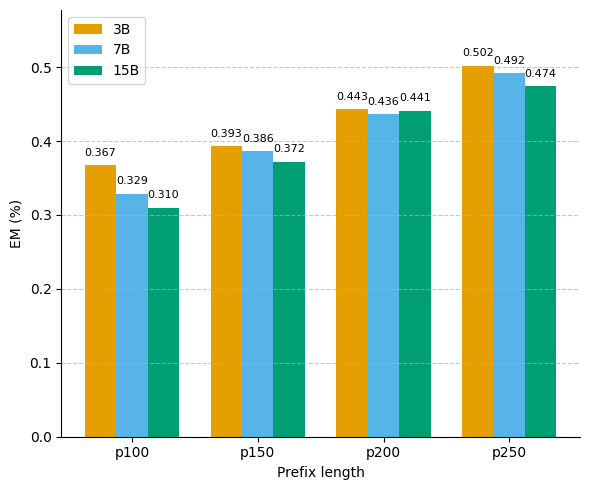

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

labels_upper = ['3B', '7B', '15B']
labels_cols  = ['3b', '7b', '15b']
colors = ['#E69F00', '#56B4E9', '#009E73']

fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(df_plen_mem_plot.index))  # Prefix length positions
width = 0.25  # Width of bars

# Create bars for each model size
for i, (lab_u, lab_c, color) in enumerate(zip(labels_upper, labels_cols, colors)):
    bars = ax.bar(x + i*width, df_plen_mem_plot[lab_c], width, label=lab_u, color=color)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_xlabel('Prefix length')
ax.set_ylabel('EM (%)')
ax.set_xticks(x + width)  # Center the tick labels
ax.set_xticklabels(df_plen_mem_plot.index)

# Adjust y-limit to accommodate labels
max_val = df_plen_mem_plot[labels_cols].max().max()
ax.set_ylim(0, max_val * 1.15)

# Create legend with rectangular patches
legend_elements = [Patch(facecolor='#E69F00', label='3B'),
                   Patch(facecolor='#56B4E9', label='7B'),
                   Patch(facecolor='#009E73', label='15B')]

plt.legend(handles=legend_elements, frameon=True, loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('attack_mem_plen_bar-all.pdf', format='pdf')

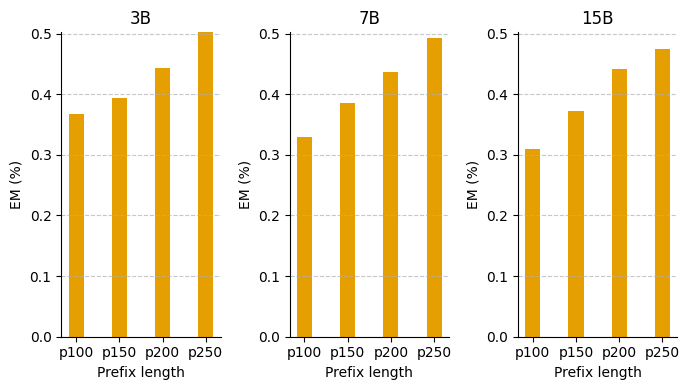

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Uses df_plen_mem_plot with columns ['3b','7b','15b'] and index like ['p100','p150','p200','p250']
#plt.rc("axes", prop_cycle=line_cycler)

labels_upper = ['3B', '7B', '15B']
labels_cols  = ['3b', '7b', '15b']   # column names in df_plen_mem_plot

#palette = {'3B': '#E69F00', '7B': '#56B4E9', '15B': '#009E73'}

fig, axes = plt.subplots(1, 3, figsize=(7, 4))
axes = axes.flatten()

bar_pos   = np.arange(len(df_plen_mem_plot.index))
bar_width = 0.35
ymax = float(df_plen_mem_plot[labels_cols].max().max())

for ax, lab_u, lab_c in zip(axes, labels_upper, labels_cols):
    ax.bar(
        bar_pos,
        df_plen_mem_plot[lab_c].values,
        width=bar_width,
        color="#E69F00",
        edgecolor='none'
    )

    # styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(lab_u)
    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM (%)')
    ax.set_ylim(0, ymax)
    ax.set_xticks(bar_pos)
    ax.set_xticklabels(df_plen_mem_plot.index)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
fig.savefig('old-attack_mem_plen_bar.pdf', format='pdf')
